In [2]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST', 'localhost')}:{os.getenv('DB_PORT', '5432')}"
    f"/{os.getenv('DB_NAME')}"
)

df = pd.read_sql("SELECT COUNT(*) AS n FROM hiring_signals", engine)
df

,n
0,82464


## Today's hiring footprint by ticker

Each ticker's "open jobs" count is the number of distinct job postings visible on their public careers site at scrape time.
This is a point-in-time inventory ("how big is each company's hiring book right now"), not a flow ("how fast are they hiring") — that comes later.

In [ ]:
today_jobs = pd.read_sql("""
    SELECT 
        ticker,
        COUNT(*)            AS n_jobs,
        COUNT(posted_date)  AS with_date,
        COUNT(category)     AS with_category,
        MIN(posted_date)    AS oldest_posted,
        MAX(posted_date)    AS newest_posted
    FROM hiring_signals
    WHERE snapshot_date = (SELECT MAX(snapshot_date) FROM hiring_signals)
    GROUP BY ticker
    ORDER BY n_jobs DESC
""", engine)

today_jobs

,ticker,n_jobs,with_date,with_category,oldest_posted,newest_posted


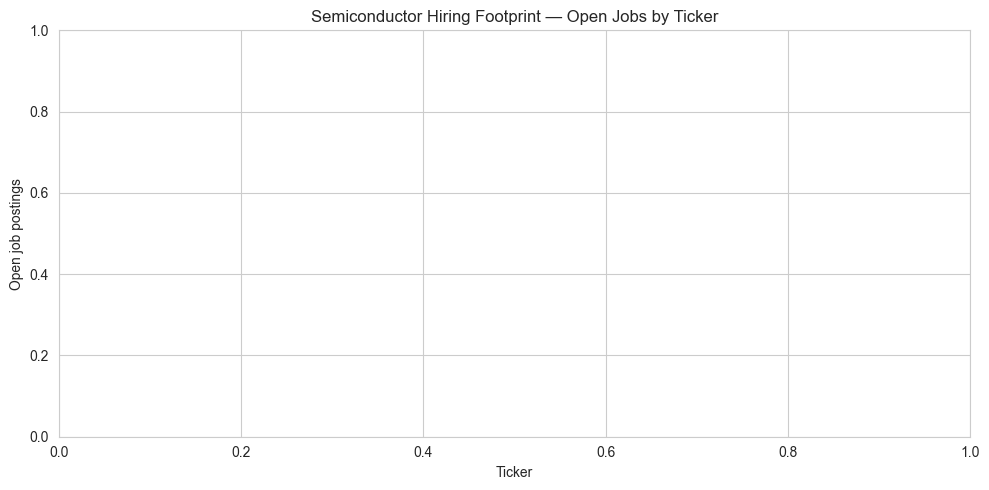

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=today_jobs,
    x="ticker", y="n_jobs",
    order=today_jobs["ticker"].tolist(),
    ax=ax, color="steelblue",
)
ax.set_title("Semiconductor Hiring Footprint — Open Jobs by Ticker")
ax.set_xlabel("Ticker")
ax.set_ylabel("Open job postings")
for i, n in enumerate(today_jobs["n_jobs"]):
    ax.text(i, n, f"{n:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### Observations (Initial observations made via Claude Guiding Questions & Discussion)

- What stands out as surprising given what you know about these companies (market cap, role, recent news)?
- What might be misleading about the comparison?
- What follow-up question does the chart make you want to ask?

-----------------------------------------------------------------------------

- **MU leads the hiring book at 3,024 open postings, ahead of NVDA's 2,654.** 
 This is surprising on first read given NVDA's profile, but likely reflects Micron's active fab expansion as they're staffing megaprojects, not just maintaining headcount. Also, differences in numbers could be attributed to companies having differing global presences/counts of involvement within different industries.

- **Raw counts overstate large/diversified companies.** 
 NVDA ~2,654 / ~42k ≈ 6.3% open-role ratio vs MU ~3,024 / ~53k ≈ 5.7%. 
 This tells us that this larger job opening count isn't as representative of the slight anomaly as expected since NVDA still has the higher hiring intensity despite the lower count due to MU having an overall higher employee count.

- **AVGO is the anomaly worth watching.**
 Broadcom despite being much larger than Cadence (~$1T market cap, ~33k employees) vs (~$90B, ~13k employees), has a very low open job listing count worth looking into.

- **Open question to test next:** 
 is the cross-ticker count driven by *global geographic spread* (`location` field) or *sector breadth* (`category` field, where available)?

In [5]:
# --- Day 10 scratch: profile location strings before normalizing ---
# Runs against the latest snapshot present (not CURRENT_DATE) so it works
# whether or not today's scrape has run yet.

loc_summary = pd.read_sql("""
    WITH latest AS (SELECT MAX(snapshot_date) AS d FROM hiring_signals)
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT location) AS distinct_locations,
        COUNT(*) FILTER (WHERE location IS NULL OR location = '') AS null_or_empty
    FROM hiring_signals, latest
    WHERE snapshot_date = latest.d
""", engine)
print(loc_summary.to_string(index=False))
print()

# Top 30 raw strings + which ATS(es) produce each
top_locs = pd.read_sql("""
    WITH latest AS (SELECT MAX(snapshot_date) AS d FROM hiring_signals)
    SELECT
        location,
        COUNT(*) AS n,
        STRING_AGG(DISTINCT ats, ', ') AS ats_sources
    FROM hiring_signals, latest
    WHERE snapshot_date = latest.d
      AND location IS NOT NULL AND location <> ''
    GROUP BY location
    ORDER BY n DESC
    LIMIT 30
""", engine)
top_locs

 total_rows  distinct_locations  null_or_empty
       8346                 400              3



,location,n,ats_sources
0,"Singapore, Singapore",879,"eightfold, jibe"
1,"Taichung City, Taichung City, Taiwan",529,eightfold
2,"Boise, Idaho, United States of America",452,eightfold
3,"San Diego, California, United States of America",363,eightfold
4,"Hyderabad, Telangana, India",345,eightfold
5,2 Locations,325,workday
6,"Bangalore, Karnataka, India",252,eightfold
7,"Hiroshima, Japan",234,eightfold
8,"Austin, Texas",223,jibe
9,"Santa Clara, CA",198,workday


In [6]:
pd.read_sql("""
    WITH latest AS (SELECT MAX(snapshot_date) AS d FROM hiring_signals)
    SELECT ats,
        COUNT(DISTINCT location) AS distinct_locations,
        COUNT(*)                 AS n_jobs
    FROM hiring_signals, latest
    WHERE snapshot_date = latest.d
    GROUP BY ats
    ORDER BY distinct_locations DESC
""", engine)

,ats,distinct_locations,n_jobs
0,workday,216,2374
1,eightfold,99,4453
2,jibe,54,1049
3,oracle_hcm,44,470
